已保存: fig8/fig8_error_contour_tricontourf_shared_colorbar.png


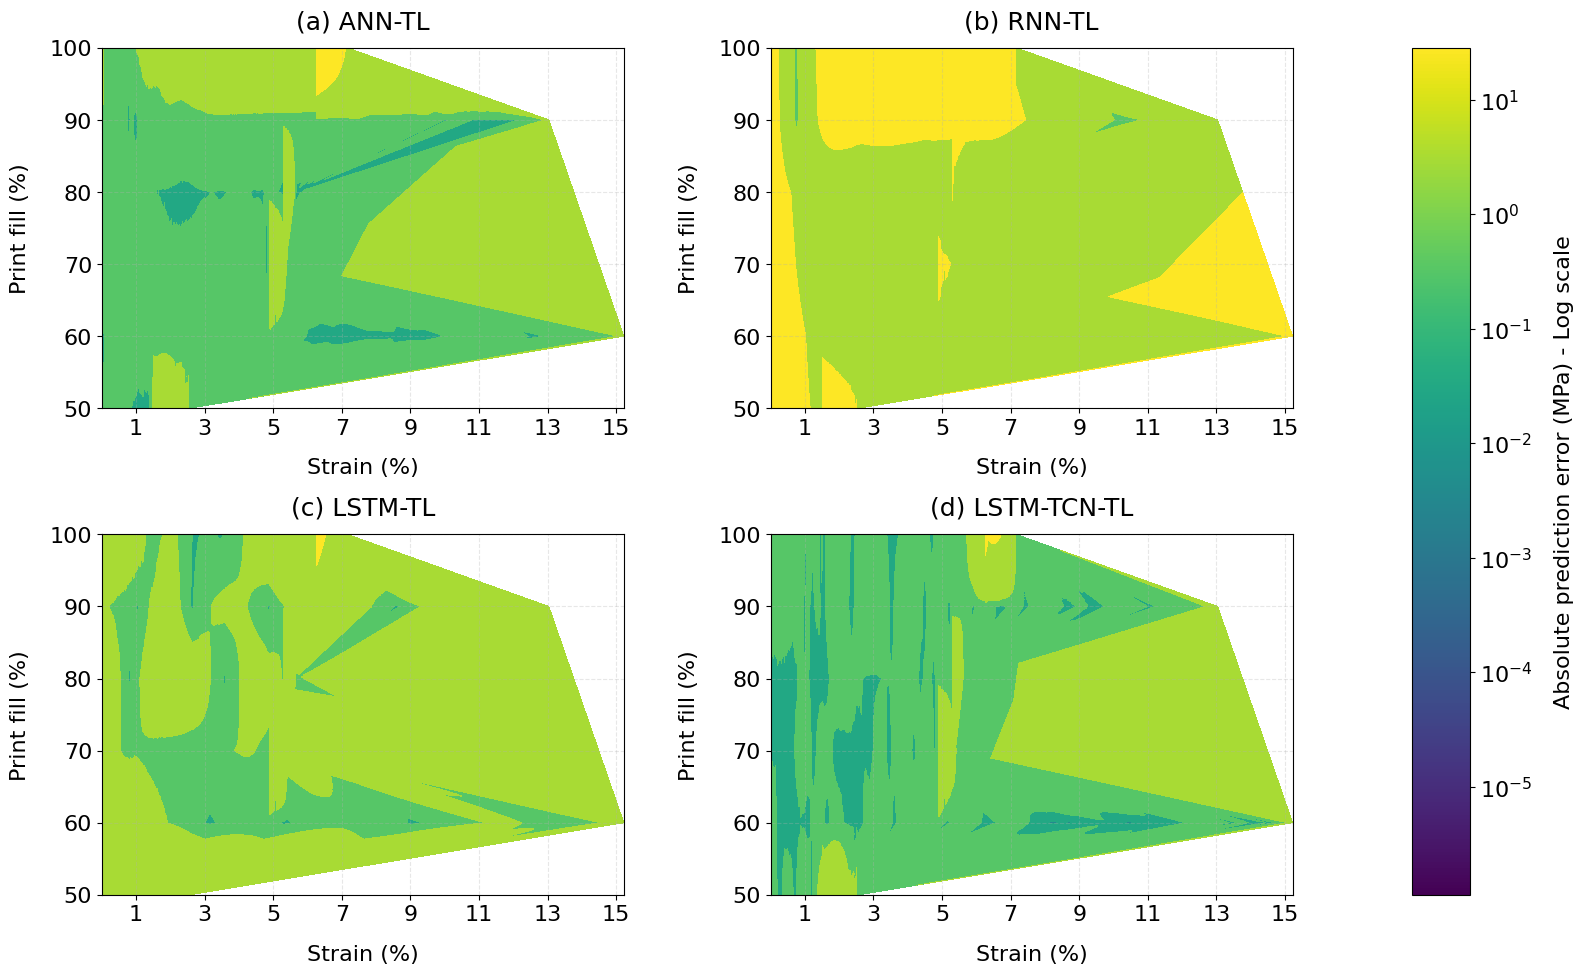

In [1]:
# 2×2 tricontourf（用所有散点）+ 四图Y轴都在左侧 + 共享LogNorm色条
# X轴刻度强制为整数；加大列间距避免相互遮挡

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# ===== 1) CSV 目录与文件名 =====
points_dir = './error_points'  # 若不在当前目录，请改绝对路径
files = {
    'ann': 'ann_tl_points.csv',
    'rnn': 'rnn_tl_points.csv',
    'lstm': 'lstm_tl_points.csv',
    'lstmtcn': 'lstm_tcn_tl_points.csv',
}

def read_points(fp: str) -> pd.DataFrame:
    df = pd.read_csv(fp)
    for c in ['Strain', 'Angle', 'Error']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['Strain', 'Angle', 'Error'])
    df = df[df['Error'] > 0]  # LogNorm 需要正值
    return df

dfs = {k: read_points(os.path.join(points_dir, v)) for k, v in files.items()}

# ===== 2) 全局 LogNorm 范围 =====
all_err = np.concatenate([df['Error'].values for df in dfs.values() if len(df) > 0])
if all_err.size < 3:
    raise ValueError('正误差点太少')
GLOBAL_VMIN = float(np.min(all_err))
GLOBAL_VMAX = float(np.max(all_err))
norm = mcolors.LogNorm(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

# ===== 3) 统一整数刻度 =====
all_strain = np.concatenate([df['Strain'].values for df in dfs.values() if len(df) > 0])
x_min, x_max = float(np.min(all_strain)), float(np.max(all_strain))
xticks = np.arange(int(np.floor(x_min)), int(np.ceil(x_max)) + 1, 2)

# ===== 4) 画布布局：2×2 子图 + 右侧色条列（不遮挡）=====
title_fs, label_fs, tick_fs, cbar_fs = 18, 16, 16, 16

fig = plt.figure(figsize=(18, 11))
# 加大两列子图间距 wspace，防止右列的 y 轴标签压到左列图像
# 加宽色条列（第三列）进一步留白
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 0.11], wspace=0.4, hspace=0.35)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
cax  = fig.add_subplot(gs[:, 2])

panels = [
    ('ann', '(a) ANN-TL', ax00),
    ('rnn', '(b) RNN-TL', ax01),
    ('lstm', '(c) LSTM-TL', ax10),
    ('lstmtcn', '(d) LSTM-TCN-TL', ax11),
]

for key, title, ax in panels:
    df = dfs[key]
    x = df['Strain'].values
    y = df['Angle'].values
    z = df['Error'].values

    ax.set_title(title, fontsize=title_fs, pad=14)
    ax.set_xlabel('Strain (%)', fontsize=label_fs, labelpad=14)
    ax.set_ylabel('Print fill (%)', fontsize=label_fs, labelpad=14)  # 四图都在左侧
    ax.tick_params(axis='both', labelsize=tick_fs)
    ax.grid(True, linestyle='--', alpha=0.3)

    ax.set_xticks(xticks)
    ax.set_xlim(x_min, x_max)

    if len(z) >= 3:
        ax.tricontourf(x, y, z, levels=100, cmap='viridis', norm=norm)
    else:
        ax.scatter(x, y, c=z, s=15, cmap='viridis', norm=norm)

# ===== 5) 共享色条（独立轴，绝不遮挡）=====

import matplotlib.ticker as mticker

mappable = plt.cm.ScalarMappable(norm=norm, cmap='viridis'); mappable.set_array([])
cbar = fig.colorbar(
    mappable,
    cax=cax,
    ticks=mticker.LogLocator(base=10.0),                 # 仅 10^k 主刻度
    format=mticker.LogFormatterMathtext(base=10.0)       # 显示成 10^{k}
)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=cbar_fs, labelpad=16)
cbar.ax.tick_params(labelsize=tick_fs)
cbar.minorticks_off()                                    # 彻底关闭次刻度


# 向左微调色条位置（数值单位为图像归一化坐标）
box = cax.get_position()
shift = 0.015  # 左移量，调大一点就更靠左
cax.set_position([box.x0 - shift, box.y0, box.width, box.height])

# ===== 6) 保存 =====
out_dir = 'fig8'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'fig8_error_contour_tricontourf_shared_colorbar.png')
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print('已保存:', out_path)
plt.show()

In [2]:
import numpy as np
import pandas as pd

# === Fig.8 分段误差统计：A0.50 / Median / P95（基于散点）===
# 输入：dfs 字典，键为 'ann'/'rnn'/'lstm'/'lstmtcn'，DataFrame 列包含 ['Strain','Angle','Error']
# 可选：percent_strain（bool），True 表示 0–7（百分数），False 表示 0.00–0.07（小数）
# 规则：
# - 在原始绝对误差上统计（不使用对数色标）
# - 排除 Angle≈50° 的点
# - 白区/无效（非有限）不计入
# - B1: <5(或0.05), B2: [5,6](或[0.05,0.06]), B3: >6(或>0.06)
# 输出：长表 long_df（Band, Model, A0.50 (%), Median (MPa), P95 (MPa)）
#       并尝试打印一个宽表视图 wide_df（不保存文件）

# 自动判断 percent_strain（若未提供）
if 'percent_strain' not in globals():
    if isinstance(dfs, dict) and len(dfs) > 0:
        all_s = np.concatenate([df['Strain'].to_numpy(dtype=float) for df in dfs.values() if 'Strain' in df])
        percent_strain = (np.nanmax(all_s) > 1.0)
    else:
        percent_strain = True  # 合理缺省

thr1, thr2 = (5.0, 7.0) if percent_strain else (0.05, 0.06)

# 模型映射（键名 → 展示名）
key_to_model = {
    'ann': 'ANN',
    'rnn': 'RNN',
    'lstm': 'LSTM',
    'lstmtcn': 'LSTM TCN',
}

rows = []

for key, model_name in key_to_model.items():
    if key not in dfs:
        continue
    df = dfs[key].copy()
    # 基础有效性：三列均为有限
    for col in ['Strain', 'Angle', 'Error']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df[np.isfinite(df['Strain']) & np.isfinite(df['Angle']) & np.isfinite(df['Error'])]

    # 排除 50°
    if np.any(np.isclose(df['Angle'].to_numpy(dtype=float), 50.0, atol=1e-6)):
        df = df[~np.isclose(df['Angle'].to_numpy(dtype=float), 50.0, atol=1e-6)]

    # 定义分段条件
    s = df['Strain'].to_numpy(dtype=float)
    bands = {
        'B1 (<5%)': s < thr1 if percent_strain else (s < thr1),
        'B2 (5 to 7%)': ((s >= thr1) & (s <= thr2)) if percent_strain else ((s >= thr1) & (s <= thr2)),
        'B3 (>7%)': s > thr2 if percent_strain else (s > thr2),
    }

    # 逐分段统计
    e = np.abs(df['Error'].to_numpy(dtype=float))
    for band_name, mask in bands.items():
        vals = e[mask]
        if vals.size == 0:
            A050 = np.nan
            med = np.nan
            p95 = np.nan
        else:
            A050 = 100.0 * np.mean(vals <= 0.50)
            med = float(np.median(vals))
            p95 = float(np.percentile(vals, 95))
        rows.append({
            'Band': band_name,
            'Model': model_name,
            'A0.50 (%)': None if np.isnan(A050) else round(A050, 1),
            'Median (MPa)': None if np.isnan(med) else float(f"{med:.3f}"),
            'P95 (MPa)': None if np.isnan(p95) else float(f"{p95:.3f}"),
        })

# 生成与打印长表
long_df = pd.DataFrame(rows, columns=['Band', 'Model', 'A0.50 (%)', 'Median (MPa)', 'P95 (MPa)'])
print('\nFig.8 segmented error statistics (points; excluding invalid & 50°):')
print(long_df.to_string(index=False))

# 可选：打印宽表
try:
    wide_df = long_df.pivot(index='Band', columns='Model', values=['A0.50 (%)', 'Median (MPa)', 'P95 (MPa)'])
    wide_df.columns = [f"{lvl2} | {lvl1}" for lvl1, lvl2 in wide_df.columns]
    wide_df = wide_df.reindex(index=['B1 (<5%)', 'B2 (5 to 7%)', 'B3 (>7%)'])
    print('\nWide view (rows=Band, columns=Model | Metric):')
    print(wide_df.to_string())
except Exception as e:
    print('\n[Info] Wide view not printed:', e)




Fig.8 segmented error statistics (points; excluding invalid & 50°):
        Band    Model  A0.50 (%)  Median (MPa)  P95 (MPa)
    B1 (<5%)      ANN       65.0         0.325      4.473
B2 (5 to 7%)      ANN       22.1         2.051     24.009
    B3 (>7%)      ANN       65.1         0.333     10.907
    B1 (<5%)      RNN        0.8         8.423     14.223
B2 (5 to 7%)      RNN        2.6         6.570     13.763
    B3 (>7%)      RNN        2.0         6.998     10.970
    B1 (<5%)     LSTM       20.1         1.028      3.166
B2 (5 to 7%)     LSTM       13.0         2.848     11.418
    B3 (>7%)     LSTM       19.3         1.231      6.136
    B1 (<5%) LSTM TCN       96.1         0.152      0.471
B2 (5 to 7%) LSTM TCN       27.3         1.664     10.974
    B3 (>7%) LSTM TCN       70.5         0.213      3.064

Wide view (rows=Band, columns=Model | Metric):
              ANN | A0.50 (%)  LSTM | A0.50 (%)  LSTM TCN | A0.50 (%)  RNN | A0.50 (%)  ANN | Median (MPa)  LSTM | Median (MPa)  